# Coursework submission for CHEM0078 Topic A4 - AI for Chemistry

## Introduction

Here, we are interested in developing a machine learning model that can predict the refractive index of unseen materials from the dataset of DFT calculated refractive indices given. The refractive index (n) is defined as the ratio of the speed of light in a vacuum (c) to the speed of light in a given material ($\nu$) - i.e. $n = \frac{c}{\nu}$.

This notebook contains a full workflow for the development of this model, including data loading, preprocessing, modelling, and evaluation, with each step clearly explained and design decisions justified.

In [147]:
# Importing useful libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import ase
import dscribe
import scipy

## Exploratory data analysis

Having generated a dataset containing computed refractive indices for various materials, the first step is to perform exploratory data analysis. The initial motivation for this is to understand the structure of the data and possibly remove any missing or erroneous values.

In [157]:
df = pd.read_pickle("data/student_dataset_2d8b9cff.pkl")
df.info()

print('\nMore information about the objects in column 0:')
print(type(df.iloc[0, 0]))
print(df.iloc[0, 0])


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1407 entries, 0 to 1406
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Atoms   1407 non-null   object 
 1   n       1407 non-null   float64
dtypes: float64(1), object(1)
memory usage: 22.1+ KB

More information about the objects in column 0:
<class 'ase.atoms.Atoms'>
Atoms(symbols='P8Pt4', pbc=True, cell=[5.75477911, 5.75477911, 5.75477911], initial_magmoms=...)


We find that we have data for 1407 materials, consisting of a crystal structure given by the `ase.atoms.Atoms` objects and a refractive index which is dimensionless by definition. In order to make the data easier to analyse, we can introduce an additional column that simply lists the atomic formula of the material, taken directly from the `ase.atoms.Atoms` object. As well as this, we will add a column that contains a list of all the atomic symbols found in the chemical formula, which will allow us to manipulate the structural data more easily to obtain various descriptions of the materials.


In [158]:
# Creating new columns with the chemical formula of the materials

df["Chemical Formula"] = df['Atoms'].apply(lambda atoms: atoms.get_chemical_formula())
df["List of atoms"] = df['Atoms'].apply(lambda atoms: atoms.symbols)

# Creating a new column with the unique elements in each material
df['Unique elements'] = [list(set(s)) for s in df['List of atoms']]

#Creating a dictionary with the number of times each element appears in the dataset
element_list = df["Unique elements"].tolist()

element_counts = {}
for material in element_list:
    for element in material:
        if element in element_counts:
            element_counts[element] += 1
        else:
            element_counts[element] = 1

print(f"There are {len(element_counts)} unique elements in the dataset.")
print(f"The most common element is {max(element_counts, key=element_counts.get)} with {max(element_counts.values())} occurrences.")

#print(element_counts['Li'], element_counts['Na'], element_counts['K'], element_counts['Rb'], element_counts['Cs'])

non_periodic = 0
for mat in df['Atoms']:
    if not mat.get_pbc().all():
        non_periodic += 1

if non_periodic > 0:
    print(f"There are {non_periodic} non-periodic materials in the dataset.")
else:
    print("There are only periodic materials in the dataset.")
        

There are 77 unique elements in the dataset.
The most common element is O with 665 occurrences.
There are only periodic materials in the dataset.


We can now start by analysing each variable (material structure and refractive index) independently to get a sense of which types of materials are prevalent in our dataset and what the distribution of refractive indices looks like.

### Analysis of refractive index data

We now move on to univariate analysis on the data given for the refractive index of each material. This data is already quantitative and continuous, making analysis more straightforward.

In [159]:
# Summary statistics for the refractive index

df['n'].describe()

count    1407.000000
mean        3.983140
std        14.232948
min         1.000000
25%         1.678075
50%         2.070657
75%         2.638278
max       149.674561
Name: n, dtype: float64

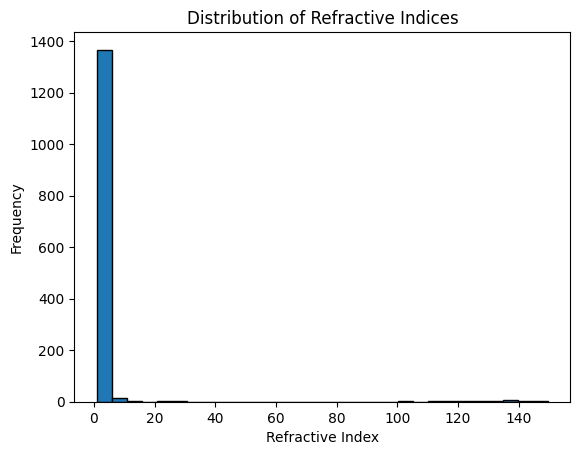

In [160]:
# Plotting the distribution of refractive indices with a histogram

plt.hist(df['n'], bins=30, edgecolor="black")
plt.xlabel("Refractive Index")
plt.ylabel("Frequency")
plt.title("Distribution of Refractive Indices")
plt.show()

In [161]:
outliers = df[df['n'] > 100]

print(f"There are {len(outliers)} materials with a refractive index greater than 100 in the dataset:")

There are 18 materials with a refractive index greater than 100 in the dataset:


We immediately find that there is a large standard deviation in the dataset, caused by the presence of apparent outliers. A quick search of the literature shows that refractive indices (measured experimentally) over 5 are exceedingly rare in inorganic materials (Batsanov, 2016), meaning we can be almost entirely confident that datapoints over 100 are innaccurate (perhaps arising from unconverged DFT calculations) and should be discarded.

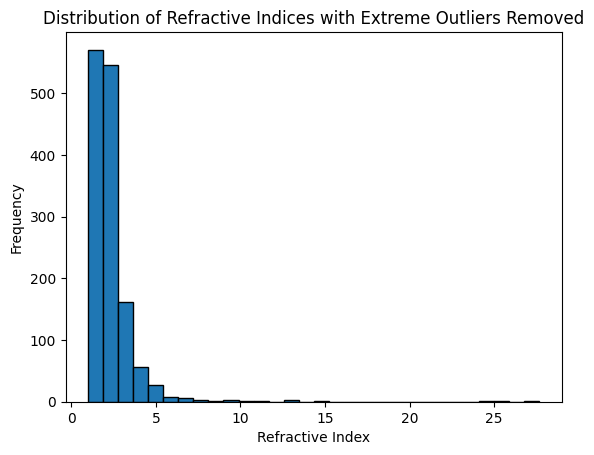

In [162]:
df = df[df['n'] <= 100]

plt.hist(df['n'], bins=30, edgecolor="black")
plt.xlabel("Refractive Index")
plt.ylabel("Frequency")
plt.title("Distribution of Refractive Indices with Extreme Outliers Removed")
plt.show()

Having removed the datapoints with refractive indices over 100, we now see that there is a small number of materials with $n \approx 25$. These values are still quite far outside the range of values that we expect from experimental results ($1 \le n \le 5$) but it is not immediately obvious whether they should be removed.

In [163]:
outliers = df[df['n'] > 20]

print(f"There are {len(outliers)} materials with a refractive index greater than 20 in the dataset:")

top10ndf = df.nlargest(10, "n")
print("The 10 materials with the highest refractive index are:")
print(top10ndf[["Chemical Formula", "n"]])


There are 3 materials with a refractive index greater than 20 in the dataset:
The 10 materials with the highest refractive index are:
     Chemical Formula          n
529           LiMn4O8  27.654889
424         Cu2Si4Zr2  25.192293
1014            NaO2V  24.141936
126           Ca2HgSn  15.012490
749             Br2Fe  12.891263
223          N8Sn4Zn4  12.604127
1273           Cl2OOs  11.357104
1095           Li5Sn2  10.537710
164       Ba12N48Re24   9.538562
1263             HgIn   9.470181


We see that there is a large very gap of almost 10 between the cluster of 3 datapoints around 25 and the rest of the data, which have a relatively smooth distribution of refractive indices between approximately $1 \le n \le 15$. Considering this alongside the fact that refractive indices over 25 are shown to be highly unlikely from experiment, we choose to also remove these 3 data points.

While it is expected that refractive indices in the range of $5 \le n \le 15$ are heavily overestimated, the fact that there is a smooth distribution of datapoints over this range suggests that this error might arise from systematic innacuracy in the DFT calculations, rather than from lack of convergence or other more extreme errors. We keep these values in the dataset since they may still provide some qualitative information and aren't expected to intefere too much with model convergence. Despite that, we will keep this in mind moving forward and may be required to remove these datapoints at a later time.

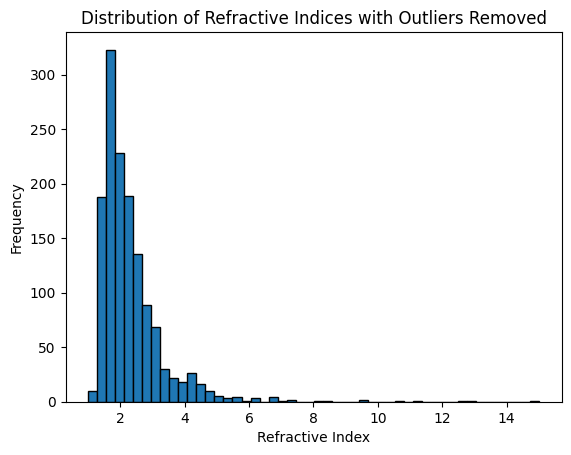

count    1386.000000
mean        2.333858
std         1.123019
min         1.000000
25%         1.675240
50%         2.056079
75%         2.605872
max        15.012490
Name: n, dtype: float64

In [164]:
df = df[df['n'] <= 20]

plt.hist(df['n'], bins=50, edgecolor="black")
plt.xlabel("Refractive Index")
plt.ylabel("Frequency")
plt.title("Distribution of Refractive Indices with Outliers Removed")
plt.show()


df['n'].describe()

We find that now the summary statistics for the refractive indices look reasonable. The standard deviation is 1.12, which is similar to the interquartile range of 0.93


### Analysis of material structures

We start by analysing the nature of the materials in our dataset. We want to do some basic analysis to ascertain which types of materials are represented more than others, and later inspect whether there is any obvious correlation between classes of materials and refractive index.

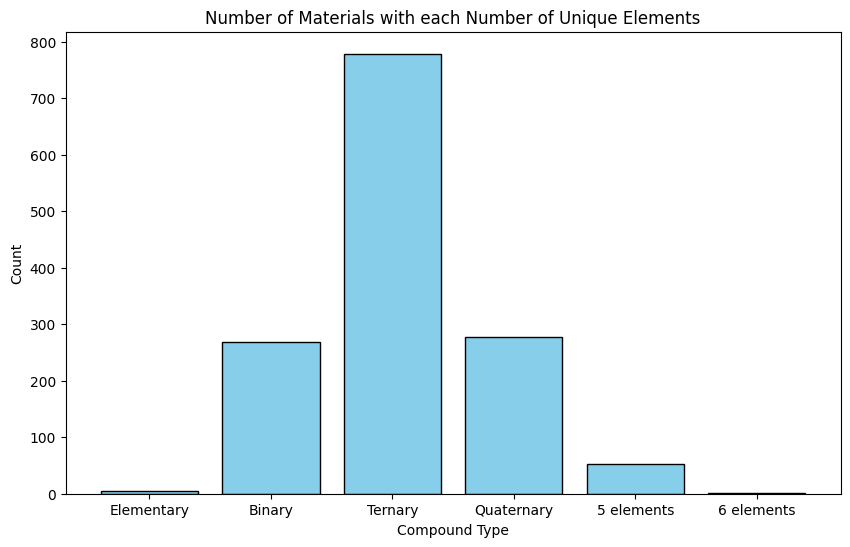

In [165]:

# Classifying how many distinct elements are in present in each material
def get_number_of_elements(unique_atom_list):
    unique_atoms = len(unique_atom_list)
    if unique_atoms == 1:
        return "Elementary"
    elif unique_atoms == 2:
        return "Binary"
    elif unique_atoms == 3:
        return "Ternary"
    elif unique_atoms == 4:
        return "Quaternary"
    else:
        return f"{unique_atoms} elements"


df["Number of Unique Elements"] = df["Unique elements"].apply(get_number_of_elements)

# Plotting the distribution of the number of unique elements in the materials with a bar chart
classes = ["Elementary", "Binary", "Ternary", "Quaternary", "5 elements", "6 elements"]
counts = df["Number of Unique Elements"].value_counts().reindex(classes, fill_value=0)
plt.figure(figsize=(10, 6))
plt.bar(counts.index, counts.values, color="skyblue", edgecolor="black")
plt.xlabel("Compound Type")
plt.ylabel("Count")
plt.title("Number of Materials with each Number of Unique Elements")
plt.show()



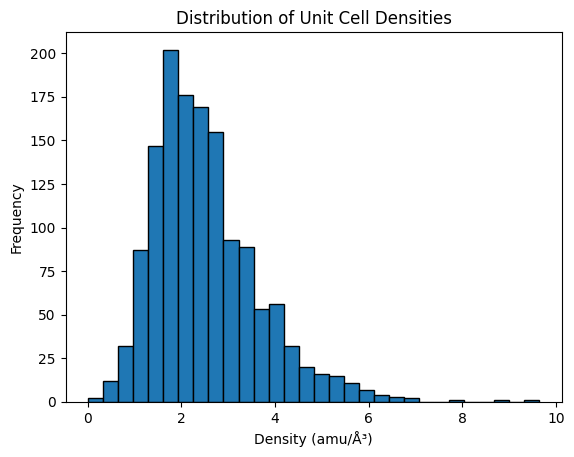

In [166]:
# Seeing the distribution of unit cell densities in the dataset

def get_density(Atoms_obj):
    cell_volume = Atoms_obj.get_volume() # in Anstrom^3
    mass = Atoms_obj.get_masses().sum() # in atomic mass units
    return mass / cell_volume

df['Unit Cell Density'] = df['Atoms'].apply(get_density)

plt.hist(df['Unit Cell Density'].tolist(), bins=30, edgecolor="black")
plt.xlabel("Density (amu/Å³)")
plt.ylabel("Frequency")
plt.title("Distribution of Unit Cell Densities")
plt.show()


We see that there is a relatively symmetric distribution of unit cell densities in the sample. As for the number of unique elements in the material, the vast majority of materials have 2, 3 or 4 elements. We may expect different behaviour for elementary compounds compared to others, although there are few of them in the dataset so it shouldn't introduce any significant trouble.

### Multivariate data analysis

We now move on to analyse what relationships and correlations might exist between our structure and refractive index in our material. We can examine these relationships using the parameters that we described previously to categorise the structure - i.e. the unit cell density and the number of unique elements in each material. We can start by using the `matminer` library to generate features for each of the materials in our dataset. This gives us access to basic properties of the materials like the mean electronegativity of their constituent elements. We can then calculate the correlation between these properties and the refractive index to gain insight into which aspect's of material composition have the largest influence on the refractive index.

ElementProperty: 100%|██████████| 1386/1386 [00:01<00:00, 850.63it/s]


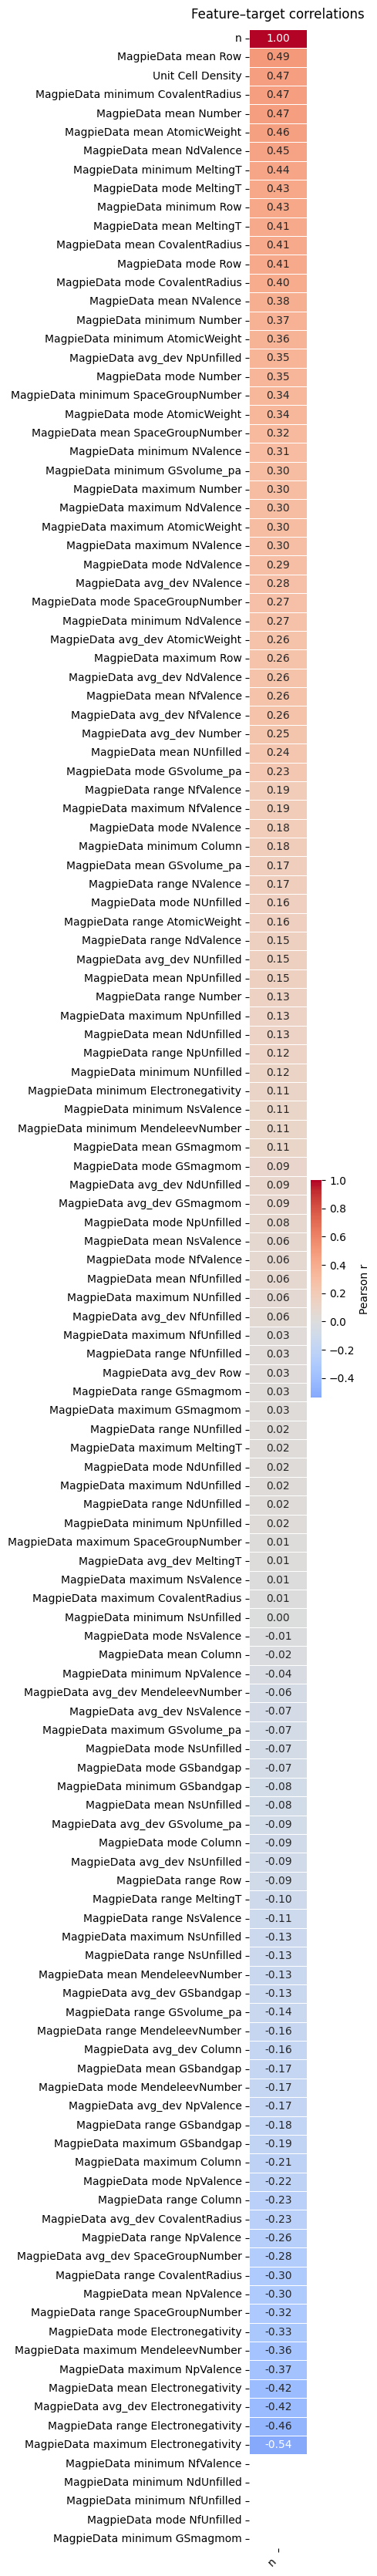

In [167]:
# Generating features about the materials from matminer

from matminer.featurizers.conversions import StrToComposition
from matminer.featurizers.composition import ElementProperty

df_comp = StrToComposition().featurize_dataframe(df, col_id='Chemical Formula')

ep_feat = ElementProperty.from_preset("magpie")

df_feat = ep_feat.featurize_dataframe(df_comp, col_id='composition')

target = "n"
corrs = df_feat.corr(numeric_only=True)[[target]].sort_values(by=target, ascending=False)

plt.figure(figsize=(5, len(corrs) * 0.25))  # scale height to number of features
ax = sns.heatmap(
    corrs,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    cbar_kws={"label": "Pearson r"},
    linewidths=0.5,
    linecolor="white"
)

# Fix ticklabel alignment
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, va="center")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

plt.title("Feature–target correlations", pad=10)
plt.tight_layout()
plt.show()

Original feature count: 140
Filtered feature count: 18


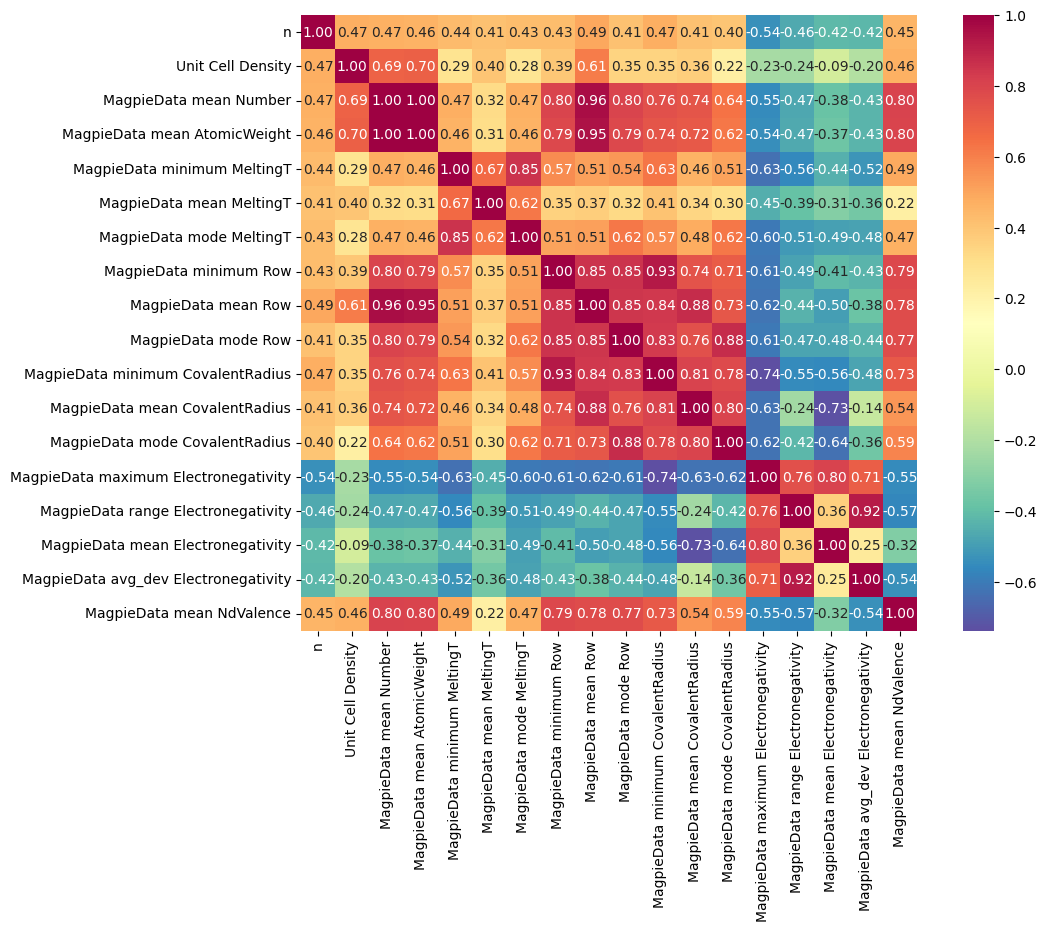

In [168]:
# Retaining only relevant features (with highest correlations) and looking at the correlations between these features.

corrs = df_feat.corr(numeric_only=True)[['n']]

# Selecting features where the absolute value of the correlation is > 0.4
relevant_features = corrs[corrs.abs() > 0.4].dropna().index.tolist()

if target in relevant_features:
    relevant_features.append(target)

df_filtered = df_feat[relevant_features]
df_filtered = df_filtered.loc[:, ~df_filtered.columns.duplicated()]

print(f"Original feature count: {len(df_feat.columns)}")
print(f"Filtered feature count: {len(df_filtered.columns)}")

corrmat = df_filtered.corr()

plt.figure(figsize=(12,8))
hm = sns.heatmap(corrmat,
                 cbar=True,
                 annot=True,
                 square=True,
                 fmt='.2f',
                 annot_kws={'size': 10},
                 yticklabels=df_filtered.columns,
                 xticklabels=df_filtered.columns,
                 cmap="Spectral_r")
plt.show()

We can see that there are several features that are highly correlated with eachother. This is most clearly seen with features that describe the 'sizes' or weights of constituent elements in the materials:
- We can remove features like the `mean Row` and `mean Number` since they are highly correlated with the `mean AtomicWeight`. 
- Similarly, the `mode Row` and `mimimum Row` features are highly correlated with the `mode CovalentRadius` and `minumum CovalentRadius` features, so can be removed.
- The mean number of d-valence electrons (`mean NdValence`) shows strong correlation with the `mean AtomicWeight`, so this feature can also be removed.
- Only one of the electronegativity range and the electronegativity standard deviation need to be retained. We choose to keep the `range Electronegativity` since it is slightly higher correlated with the refractive index and is conceptually simpler.
- Similarly, the `mimumum MeltingT` and the `mode MeltingT` are highly correlated so we retain the mimimum melting temperature.

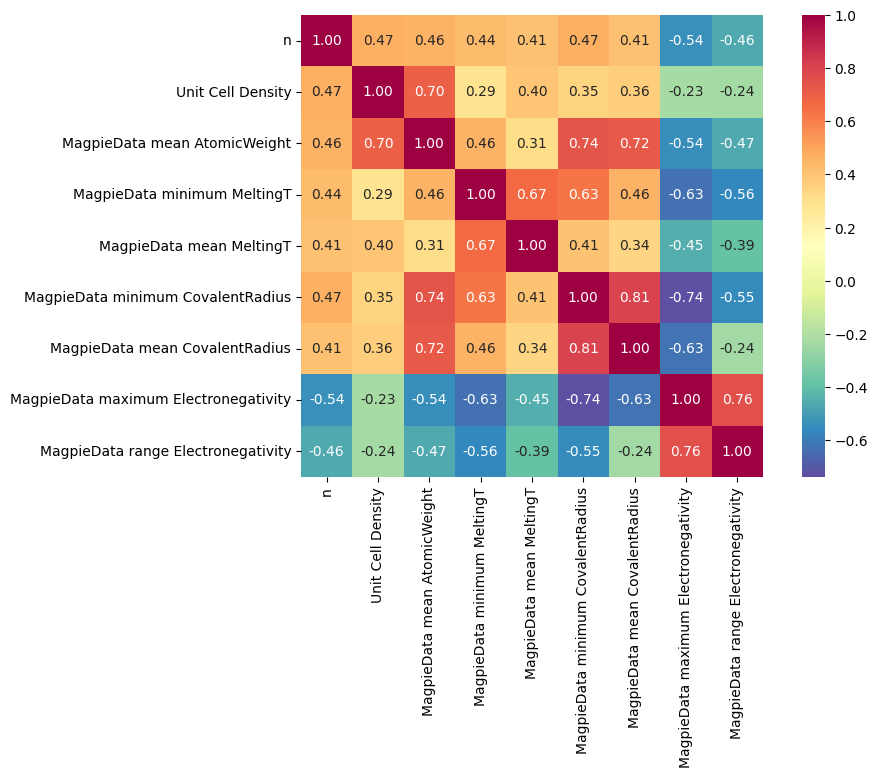

In [169]:
correlated_features = ['MagpieData mean Number', 'MagpieData mean Row', 'MagpieData mode Row', 'MagpieData minimum Row', 'MagpieData mode CovalentRadius', 
                       'MagpieData avg_dev Electronegativity', 'MagpieData mean Electronegativity', 'MagpieData mode MeltingT', 'MagpieData mean NdValence']

df_filtered = df_filtered.drop(columns=correlated_features)

corrmat = df_filtered.corr()

plt.figure(figsize=(10,6))
hm = sns.heatmap(corrmat,
                 cbar=True,
                 annot=True,
                 square=True,
                 fmt='.2f',
                 annot_kws={'size': 10},
                 yticklabels=df_filtered.columns,
                 xticklabels=df_filtered.columns,
                 cmap="Spectral_r")
plt.show()

We now have a set of 7 features that appear to be relevant in predicting the refractive index of a material. Missing from these features is a description of the density of these materials, which is hypothesised to be important for describing refractive index. Before proceeding, we quickly plot the correlation the unit cell density and the refractive index.

R^2 value for the linear regression: 0.2230


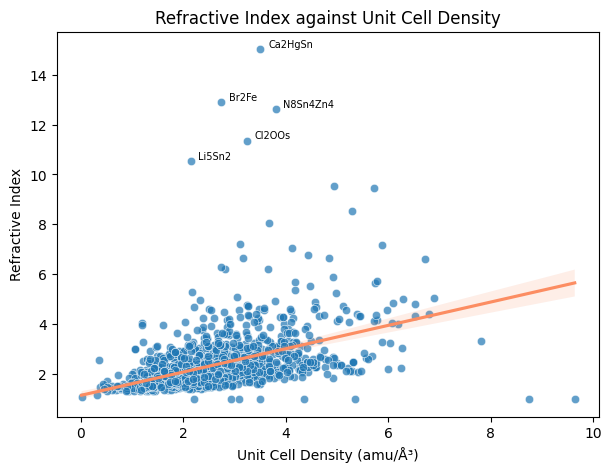

In [170]:
# Examining the realtionship between the refractive index and the unit cell density.

# Computing R^2 for a linear regression between the refractive index and the unit cell density
x = df["Unit Cell Density"].values
y = df["n"].values

coeffs = np.polyfit(x, y, deg=1)
y_pred = np.polyval(coeffs, x)

ss_res = np.sum((y - y_pred)**2)
ss_tot = np.sum((y - np.mean(y))**2)
r2 = 1 - ss_res/ss_tot

print(f"R^2 value for the linear regression: {r2:.4f}")


# Plotting the relationship between the refractive index and the unit cell density with a scatterplot and a regression line
plt.figure(figsize=(7,5))
# Scatterplot
sns.scatterplot(
    data=df,
    x="Unit Cell Density",
    y="n",
    alpha=0.7
)
# Regression line
sns.regplot(
    data=df,
    x="Unit Cell Density",
    y="n",
    scatter=False,
    color=sns.color_palette("Set2")[1]
)

outliers = df[df['n'] > 10]
for _, row in outliers.iterrows():
    plt.text(
        row["Unit Cell Density"] + 0.15,
        row["n"],
        row["Chemical Formula"], 
        fontsize=7,
        ha="left",
        va="bottom"
    )

plt.xlabel("Unit Cell Density (amu/Å³)")
plt.ylabel("Refractive Index")
plt.title("Refractive Index against Unit Cell Density")
plt.show()

We indeed find a relatively weak but convincing positive correlation between the unit cell density and the refractive index. This makes sense physically: from a simplistic perspective, a high refractive index implies that light finds struggles to travel through a material, which would be expected for a material with a higher density.

This plot also makes us turn attention back to the data points with $n \lt 10$. We see that these points don't reflect this correlation at all, possessing very high refractive indices but only average densities. This provides further evidence for removing these materials from the dataset. The only thing that obviously links some of these chemical structures together is the presence of tin in three of the materials. We can quickly check below whether the data shows that tin containing materials exhibit unusually high refractive indices.

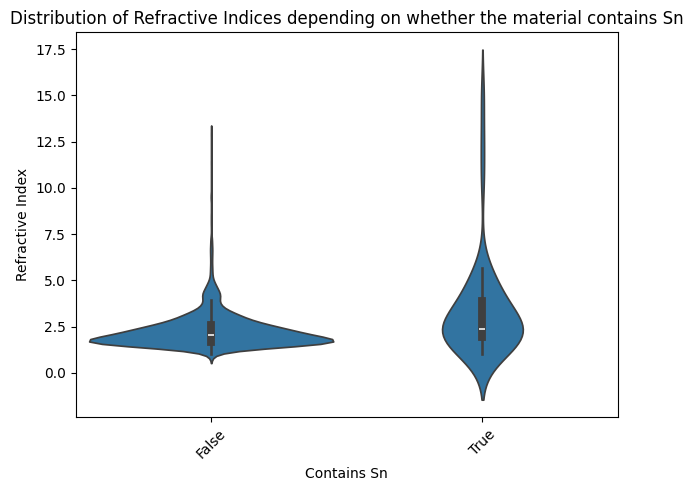

In [207]:
df["Contains Sn"] = df["Unique elements"].apply(lambda elems: "Sn" in elems)

plt.figure(figsize=(7, 5))
sns.violinplot(data=df, 
               x="Contains Sn", y="n", width=0.9)
plt.xticks(rotation=45)
plt.ylabel("Refractive Index")
plt.title("Distribution of Refractive Indices depending on whether the material contains Sn")
plt.show()

df = df.drop(columns=["Contains Sn"])


There doesn't appear to be any significant evidence that the presence of Tin in the outlier materials could explain their unusually high refractive indices. As such, we believe it is justified to remove the 5 materials that have refractive indices over 10 from the dataset. We thus move on to quickly examine any simple relationships that might exist between the composition of the materials and their refractive indices.

In [171]:
# Removing outliers as mentioned above
df = df[df['n'] <= 10]

df['n'].describe()

count    1381.000000
mean        2.297121
std         0.939647
min         1.000000
25%         1.674381
50%         2.040749
75%         2.594908
max         9.538562
Name: n, dtype: float64

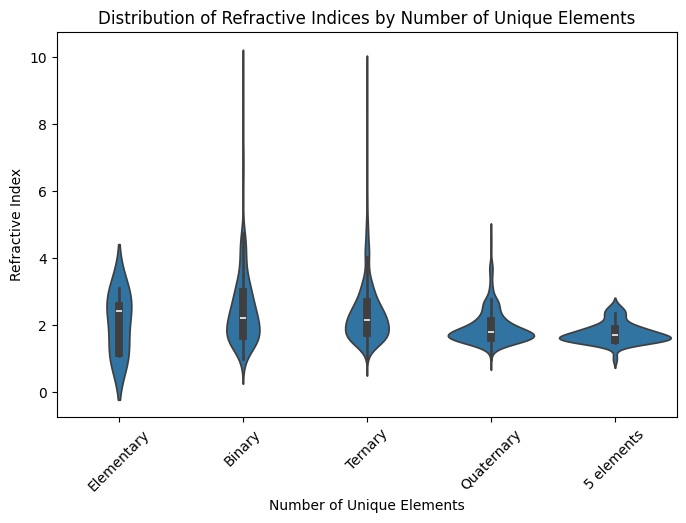

In [209]:

classes = ["Elementary", "Binary", "Ternary", "Quaternary", "5 elements"]

plt.figure(figsize=(8, 5))
sns.violinplot(data=df[df["Number of Unique Elements"] != "6 elements"],  # Exclude the "6 elements" class as it only has 1 material
               x="Number of Unique Elements", y="n", order=classes, width=0.9)
plt.xticks(rotation=45)
plt.ylabel("Refractive Index")
plt.title("Distribution of Refractive Indices by Number of Unique Elements")
plt.show()


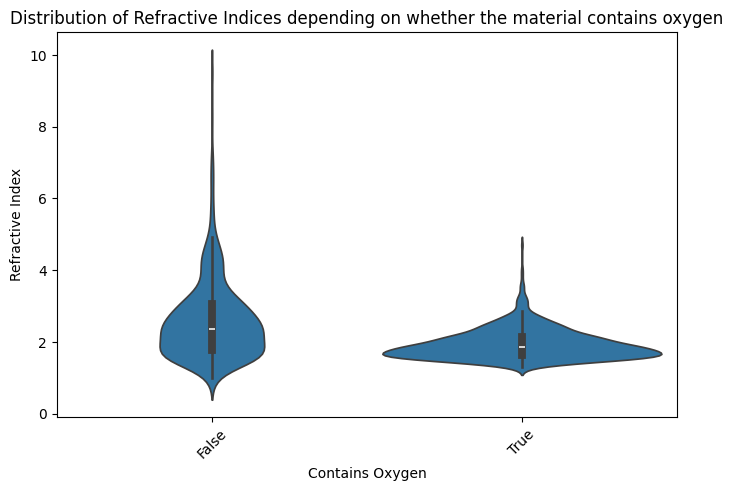

In [21]:
# Since Oxygen is found so commonly in the dataset, we may want to characterise materials based on whether they contain oxygen or not.

df["Contains Oxygen"] = df['Atoms'].apply(lambda atoms: "O" in atoms.symbols)

import seaborn as sns

plt.figure(figsize=(8, 5))
sns.violinplot(data=df, 
               x="Contains Oxygen", y="n", width=0.9)
plt.xticks(rotation=45)
plt.ylabel("Refractive Index")
plt.title("Distribution of Refractive Indices depending on whether the material contains oxygen")
plt.show()

df = df.drop(columns=["Contains Oxygen"])

Finally, we see that the number of different elements in the material doesn't appear to have a strong impact on the material's refractive index. There is no evidence that it is worth adding this as a descriptor of the material. The presence of oxygen does seem to impact the refractive index slightly, suggesting that the nature of bonding may be different on average between materials with or without oxygen.

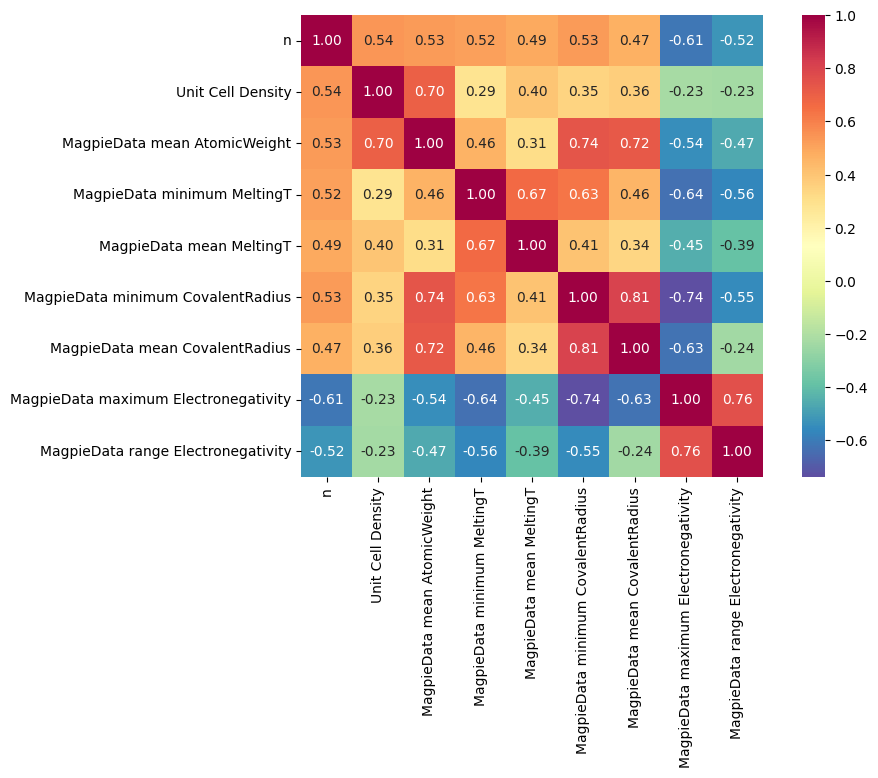

In [172]:
df_filtered = df_filtered[df_filtered['n'] <= 10]
df_filtered['Unit Cell Density'] = df['Unit Cell Density'].values

corrmat = df_filtered.corr()

plt.figure(figsize=(10,6))
hm = sns.heatmap(corrmat,
                 cbar=True,
                 annot=True,
                 square=True,
                 fmt='.2f',
                 annot_kws={'size': 10},
                 yticklabels=df_filtered.columns,
                 xticklabels=df_filtered.columns,
                 cmap="Spectral_r")
plt.show()


## Chemical Descriptors


Having gained some useful insights into our dataset, we move on to consider the best way to represent the structural data we have for each material.

We first need to consider what information our representation needs to contain in order to get an accurate mapping from the chemical structure to the refractive index. We have already identified a set of 8 material features that appear to be relevant in determining a material's refractive index. A simple strategy would be to use these as property based descriptors. Since the refractive index is a bulk property, we can imagine that relatively crude descriptors like the mean atomic number might still be able to provide a useful mapping.


In [173]:
from sklearn.preprocessing import StandardScaler
# Basic numpy array containing 8 features for each material

x_feats = df_filtered.values[:, 1:]
y = df_filtered.values[:,0]

scaler_x = StandardScaler()
x_feats = scaler_x.fit_transform(x_feats)
scaler_y = StandardScaler()
y = scaler_y.fit_transform(y.reshape(-1, 1))

However, considering that the refractive index roughly measures how light passes through a crystal and interacts with the atoms/ions in it, it also seems possible that a geometric description of atoms our materials will be important for getting an accurate relationship. In the same way that different polymorphs of a crystal are likely to scatter X-rays differently and produce different X-ray diffraction patterns, we can assume that visible light will also be scattered differently even by materials with the same constituent atoms but in different arrangements.

As such, we also consider trying a chemical descriptor that describes both the connectivity of atoms/ions and their spatial arrangement in the unit cell. This a descriptor should be able to fully describe for the crystalline nature of the materials in our dataset, i.e. take into account periodic boundary conditions. This immediately rules out using a Coulomb matrix as a descriptor as it cannot include the theoretically infinite number of atoms/ions present in our periodic crystals. The Ewald sum matrix and Sine matrix exist roughly as extensions to the Coulomb matrix for periodic systems and are found in the `dscribe.descriptors` package. While these descriptors are relatively compact, thus making them computationally efficient, they suffer from issues like a lack of permutational invariance. They also only describe the distances between atoms/ions (2-body interactions) in the material but provide no information about bond angles (3-body interactions) which are needed for a fuller description of the geometry. 

The two most obvious descriptors that remain to choose from are SOAP (Smooth Overlap of Atomic Positions) and MBTR (Many Body Tensor Representation). Both of these descriptors can be conveniently used with periodic boundary conditions and can include information about both 2- and 3-body interactions. They have been shown to perform similarly when used in Kernel Ridge Regression workflows to predict formation energies of inorganic compounds (Hafner, 2021), however, in other applications such as band-gap predictions SOAP can sometimes produce more accurate results (Karamad, 2020). On the other hand, MBTR can yield better interpretability of results since it clearly distinguishes between 1-, 2- and 3-body interaction terms (given by the order $k$). We will attempt to use both approaches and compare them.

In [174]:
import collections.abc
collections.Iterable = collections.abc.Iterable
from dscribe.descriptors import MBTR
from ase.build import bulk

min_dist = 0.5  #smallest distance in Angstrom
max_dist = 10  #largest distance in Angstrom
#we are constructing MBTR with inverse distances
grid_min = 1.0/max_dist 
grid_max = 1.0/min_dist 
grid_n = 50 # number of grid points
sigma = 0.05
elements = list(element_counts.keys())


mbtr = MBTR(
    species=elements,
    geometry={"function": "cosine"}, 
    grid={"min": grid_min, "max": grid_max, "n": grid_n, "sigma": sigma},
    weighting={"function": "exp", "scale": 0.5, "threshold": 1e-3},
    periodic=True,
    normalization="valle_oganov", # Normalises based on the density of atoms in the unit cell.
    sparse=True
)

mbtr_test = mbtr.create(df.iloc[0,0])
mbtr_test.shape

/home/jkielty/A4_CWK/.venv/lib/python3.12/site-packages/dscribe/core/system.py:96: FutureWarning: Please use atoms.calc
  calculator=atoms.get_calculator(),


(11561550,)

We immediately find that the MBTR description is not computationally efficient for our dataset. There are 77 different elements present in the dataset, all of which need to be allocated space in the MBTR vector even when not present. This means that the MBTR vectors are very large and computations with them can be expected to be prohibitively expensive. As such, the choice is made for us and we continue by using SOAP descriptors.

Similar problems can be avoided when using SOAP vectors by averaging with `average="inner"` and by compressing features with `"mu2"`. For compression, a species weighting must be provided. This provides an opportunity to weight the various elements in the dataset according to their properties. We start with the most obvious choice of weighting by atomic numbers, but also try weighting by the electronegativity (more precisely 4 - electronegativity to reflect the negative correlation).

In [175]:
from dscribe.descriptors import SOAP
from pymatgen.core import Element

r_cut = 10 #cutoff in Angstrom
n_max = 6 #
sigma = 0.3 #stdev of gaussians
l_max = 6
atomic_numbers = {el: Element(el).Z for el in element_counts.keys()}  # Create a dictionary mapping element symbols to their atomic numbers

# Setting up the SOAP descriptor
soap = SOAP(
    species=elements,
    periodic=True,
    r_cut=r_cut,
    n_max=n_max,
    l_max=l_max,
    sigma=sigma,
    rbf="gto",
    average="inner",  # Make the SOAP descriptor global by averaging over all atoms in the unit cell
    compression={"mode": "mu2", "species_weighting": atomic_numbers}, 
    sparse=False
)

test = soap.create(df.iloc[0,0])
print(test.shape)

(147,)


In [102]:
# Building a list of soap vectors for each material
x_soap = []

for i, mat in enumerate(df['Atoms']):
    soap_mat = soap.create(mat)
    x_soap.append(soap_mat)
    if i % 100 == 0:
        print(f"Processed {i} materials")
        
scaler_x = StandardScaler()
x_soap = scaler_x.fit_transform(x_soap)

Processed 0 materials
Processed 100 materials
Processed 200 materials
Processed 300 materials
Processed 400 materials
Processed 500 materials
Processed 600 materials
Processed 700 materials
Processed 800 materials
Processed 900 materials
Processed 1000 materials
Processed 1100 materials
Processed 1200 materials
Processed 1300 materials


In [106]:
# Weighting each element with 4 - electronegativity.
electronegativities = {el: (4- Element(el).X) for el in element_counts.keys()}

soap_en = SOAP(
    species=elements,
    periodic=True,
    r_cut=r_cut,
    n_max=n_max,
    l_max=l_max,
    sigma=sigma,
    rbf="gto",
    average="inner",  # Make the SOAP descriptor global by averaging over all atoms in the unit cell
    compression={"mode": "mu2", "species_weighting": electronegativities}, 
    sparse=False
)

x_soap_en = []

for i, mat in enumerate(df['Atoms']):
    soap_mat = soap_en.create(mat)
    x_soap_en.append(soap_mat)
    if i % 100 == 0:
        print(f"Processed {i} materials")
        
scaler_x = StandardScaler()
x_soap_en = scaler_x.fit_transform(x_soap_en)

Processed 0 materials
Processed 100 materials
Processed 200 materials
Processed 300 materials
Processed 400 materials
Processed 500 materials
Processed 600 materials
Processed 700 materials
Processed 800 materials
Processed 900 materials
Processed 1000 materials
Processed 1100 materials
Processed 1200 materials
Processed 1300 materials


## Building a Model

### Testing different descriptors

/home/jkielty/A4_CWK/.venv/lib/python3.12/site-packages/sklearn/ensemble/_gb.py:680: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?


Mean squared error: 0.6017339696856132
r-squared: 0.5020432025800954


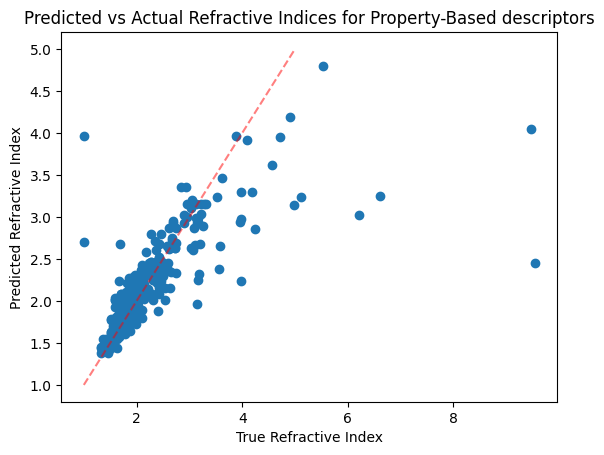

In [142]:
# First trying the property based descriptors

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

x_feats_train, x_feats_test, y_train, y_test = train_test_split(x_feats, y, random_state=0,
                                  train_size=0.8)
regr = GradientBoostingRegressor(loss='huber')
regr.fit(x_feats_train, y_train)

predictions = regr.predict(x_feats_test)
predictions_rescaled = scaler_y.inverse_transform(predictions.reshape(-1,1))
y_test_rescaled = scaler_y.inverse_transform(y_test)

plt.scatter(y_test_rescaled, predictions_rescaled)
plt.plot([1, 5], [1, 5], '--', alpha=0.5, color='red')
plt.xlabel('True Refractive Index')
plt.ylabel('Predicted Refractive Index')
plt.title('Predicted vs Actual Refractive Indices for Property-Based descriptors')

print('Mean squared error:', mean_squared_error(predictions, y_test))
print('r-squared:', r2_score(y_test, predictions))

/home/jkielty/A4_CWK/.venv/lib/python3.12/site-packages/sklearn/ensemble/_gb.py:680: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?


Mean squared error: 0.7036408404018388
r-squared: 0.41771155182843733


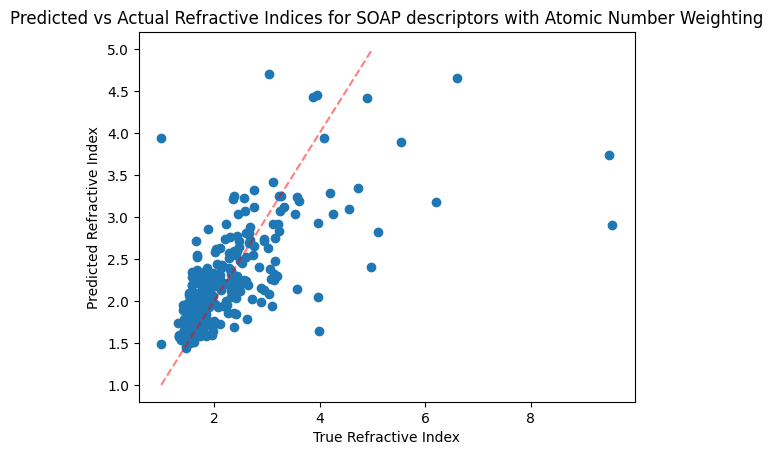

In [143]:
x_soap_train, x_soap_test, y_train, y_test = train_test_split(x_soap, y, random_state=0,
                                  train_size=0.8)
regr = GradientBoostingRegressor(loss='huber')
regr.fit(x_soap_train, y_train)

predictions = regr.predict(x_soap_test)
predictions_rescaled = scaler_y.inverse_transform(predictions.reshape(-1,1))
y_test_rescaled = scaler_y.inverse_transform(y_test)

plt.scatter(y_test_rescaled, predictions_rescaled)
plt.plot([1, 5], [1, 5], '--', alpha=0.5, color='red')
plt.xlabel('True Refractive Index')
plt.ylabel('Predicted Refractive Index')
plt.title('Predicted vs Actual Refractive Indices for SOAP descriptors with Atomic Number Weighting')

print('Mean squared error:', mean_squared_error(predictions, y_test))
print('r-squared:', r2_score(y_test, predictions))

/home/jkielty/A4_CWK/.venv/lib/python3.12/site-packages/sklearn/ensemble/_gb.py:680: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?


Mean squared error: 0.8273567505950867
r-squared: 0.31533212581413905


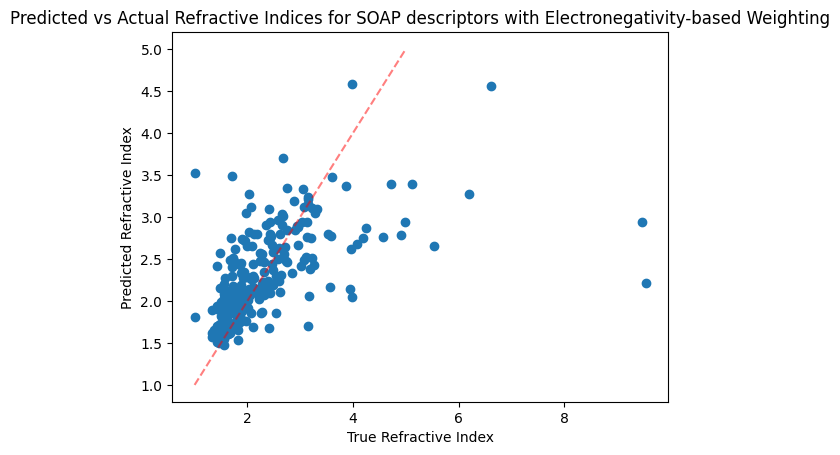

In [144]:
x_soap_en_train, x_soap_en_test, y_train, y_test = train_test_split(x_soap_en, y, random_state=0,
                                  train_size=0.8)
regr = GradientBoostingRegressor(loss='huber')
regr.fit(x_soap_en_train, y_train)

predictions = regr.predict(x_soap_en_test)
predictions_rescaled = scaler_y.inverse_transform(predictions.reshape(-1,1))
y_test_rescaled = scaler_y.inverse_transform(y_test)

plt.scatter(y_test_rescaled, predictions_rescaled)
plt.plot([1, 5], [1, 5], '--', alpha=0.5, color='red')
plt.xlabel('True Refractive Index')
plt.ylabel('Predicted Refractive Index')
plt.title('Predicted vs Actual Refractive Indices for SOAP descriptors with Electronegativity-based Weighting')

print('Mean squared error:', mean_squared_error(predictions, y_test))
print('r-squared:', r2_score(y_test, predictions))

Despite trying various different SOAP descriptors to include a geometric description of the materials, we find that the gradient boosted regressor with property-based descriptors was best able to predict the refractive index of materials in the testing dataset. As such, we will move on to optimise the hyperparameters for this model. Since the use of property-based descriptors makes training the model cheap, we can optimise 4 hyperparameters simultaneously in order to achieve better results.

### Optimising Hyperparameters

In [110]:
regr.fit(x_feats_train, y_train)

/home/jkielty/A4_CWK/.venv/lib/python3.12/site-packages/sklearn/ensemble/_gb.py:680: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?


,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'huber'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, a

In [125]:
# Optimising all parameters simultaneously

from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [50, 100, 200, 300, 400, 500],
    "learning_rate": [0.06, 0.08, 0.1 , 0.12, 0.14],
    "max_depth":range(1, 10, 5),
    "min_samples_split":range(5, 25, 5)
}

search_cv = GridSearchCV(
    GradientBoostingRegressor(loss="huber"), param_grid=param_grid,
    scoring="neg_mean_squared_error",  n_jobs=4, cv=10
)

search_cv.fit(x_feats_train, y_train.ravel())

print(search_cv.best_params_)

{'learning_rate': 0.12, 'max_depth': 6, 'min_samples_split': 5, 'n_estimators': 50}


/home/jkielty/A4_CWK/.venv/lib/python3.12/site-packages/sklearn/ensemble/_gb.py:680: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?


Mean squared error: 0.6081320018686904
r-squared: 0.4967485976945857


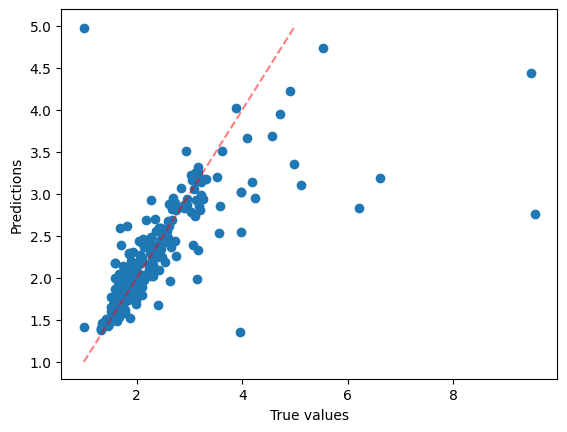

In [139]:
best_reg = GradientBoostingRegressor(loss='huber', n_estimators=50, learning_rate=0.12, max_depth=6, min_samples_split=5)
best_reg.fit(x_feats_train, y_train)

predictions = best_reg.predict(x_feats_test)
predictions_rescaled = scaler_y.inverse_transform(predictions.reshape(-1,1))
y_test_rescaled = scaler_y.inverse_transform(y_test)

plt.scatter(y_test_rescaled, predictions_rescaled)
plt.plot([1, 5], [1, 5], '--', alpha=0.5, color='red')
plt.xlabel('True Refractive Index')
plt.ylabel('Predicted Refractive Index')

print('Mean squared error:', mean_squared_error(predictions, y_test))
print('r-squared:', r2_score(y_test, predictions))

Curiously, we find that the supposedly optimised hyperparameters obtained from a parameter grid search do not appear to improve the model fit. We are stuck at a $R^2$ of approximately 0.5 and a mean absolute error of approximately 0.6.

## Citations

- Batsanov, S. S., Ruchkin, E. D. & Poroshina, I. A., Refractive Indices of Solids, Springer Singapore, 2013
- Hafner, L. et al. DScribe: Library of descriptors for machine learning in materials science. Comput. Phys. Commun. 260, 107683 (2021).
- Karamad, M. et al. Orbital graph convolutional neural network for material property prediction. Phys. Rev. Materials 4, 093801 (2020).